In [13]:
# %% [markdown]
# # Overtake Trial Classification
# For each session, classifies overtake trials as:
# - **Would-be correct** — heading toward the target stimulus
# - **Would-be wrong** — heading toward the distractor
# - **Unclear** — insufficient trajectory data

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import sys

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from scripts.utils import (flag_overtakes, get_target_side,
                            classify_path_side, session_summary, load_session, session_summary)

In [15]:
# %%
# ── Define session files ───────────────────────────────────────
SESSION_FILES = {
    "Session 1 (June15)" : r"C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\June15\test01_June15.pkl",
    "Session 2 (May18-1)": r"C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\May18\test01_May18.pkl",
    "Session 3 (May18-2)": r"C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\May18\test02_May18.pkl",
    "Session 4 (June2)"  : r"C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\June2\test01_June2.pkl",
}

In [16]:
from scripts.utils import load_session, session_summary

sessions = {}
for name, path in SESSION_FILES.items():
    data = load_session(path)
    sessions[name] = data
    session_summary(data, name)

Loaded 400 trials from C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\June15\test01_June15.pkl

── Session 1 (June15) ──────────────────────────
  Total trials : 400
  Correct      : 283  (70.8%)
  Wrong        : 60    (15.0%)
  Overtakes    : 57 (14.2%)

  Overtake breakdown:
    would_be_correct: 47 (82.5%)
    would_be_wrong: 10 (17.5%)
Loaded 185 trials from C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\May18\test01_May18.pkl

── Session 2 (May18-1) ──────────────────────────
  Total trials : 185
  Correct      : 138  (74.6%)
  Wrong        : 32    (17.3%)
  Overtakes    : 15 (8.1%)

  Overtake breakdown:
    would_be_correct: 13 (86.7%)
    would_be_wrong: 2 (13.3%)
Loaded 200 trials from C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\May18\test02_May18.pkl

── Session 3 (May18-2) ──────────────────────────
  Total trials : 200
  Correct      : 156  (78.0%)
  Wrong        : 26    (13.0%)
  Overtakes    : 18 (9.0%)

  Overtake breakdown:
    would_be_

In [17]:
# %%
# ── Step 1: validate on correct trials ────────────────────────
print("Validating slope method on correct trials:\n")

for name, data in sessions.items():
    correct = data[data["Correct"].astype(bool)].copy()
    mismatch = correct[correct["hit_side"] != correct["target_side"]]
    total = len(correct[correct["hit_side"].notna()])
    pct = (1 - len(mismatch)/total)*100 if total > 0 else 0
    print(f"{name}: {pct:.1f}% of correct trials — path matched target side")

Validating slope method on correct trials:

Session 1 (June15): 99.3% of correct trials — path matched target side
Session 2 (May18-1): 97.8% of correct trials — path matched target side
Session 3 (May18-2): 98.7% of correct trials — path matched target side
Session 4 (June2): 99.6% of correct trials — path matched target side



Session 1 (June15) — overtake outcomes:
hypothetical_outcome
would_be_correct    47
would_be_wrong      10
Name: count, dtype: int64

Session 2 (May18-1) — overtake outcomes:
hypothetical_outcome
would_be_correct    13
would_be_wrong       2
Name: count, dtype: int64

Session 3 (May18-2) — overtake outcomes:
hypothetical_outcome
would_be_correct    14
would_be_wrong       4
Name: count, dtype: int64

Session 4 (June2) — overtake outcomes:
hypothetical_outcome
would_be_correct    26
would_be_wrong       7
Name: count, dtype: int64


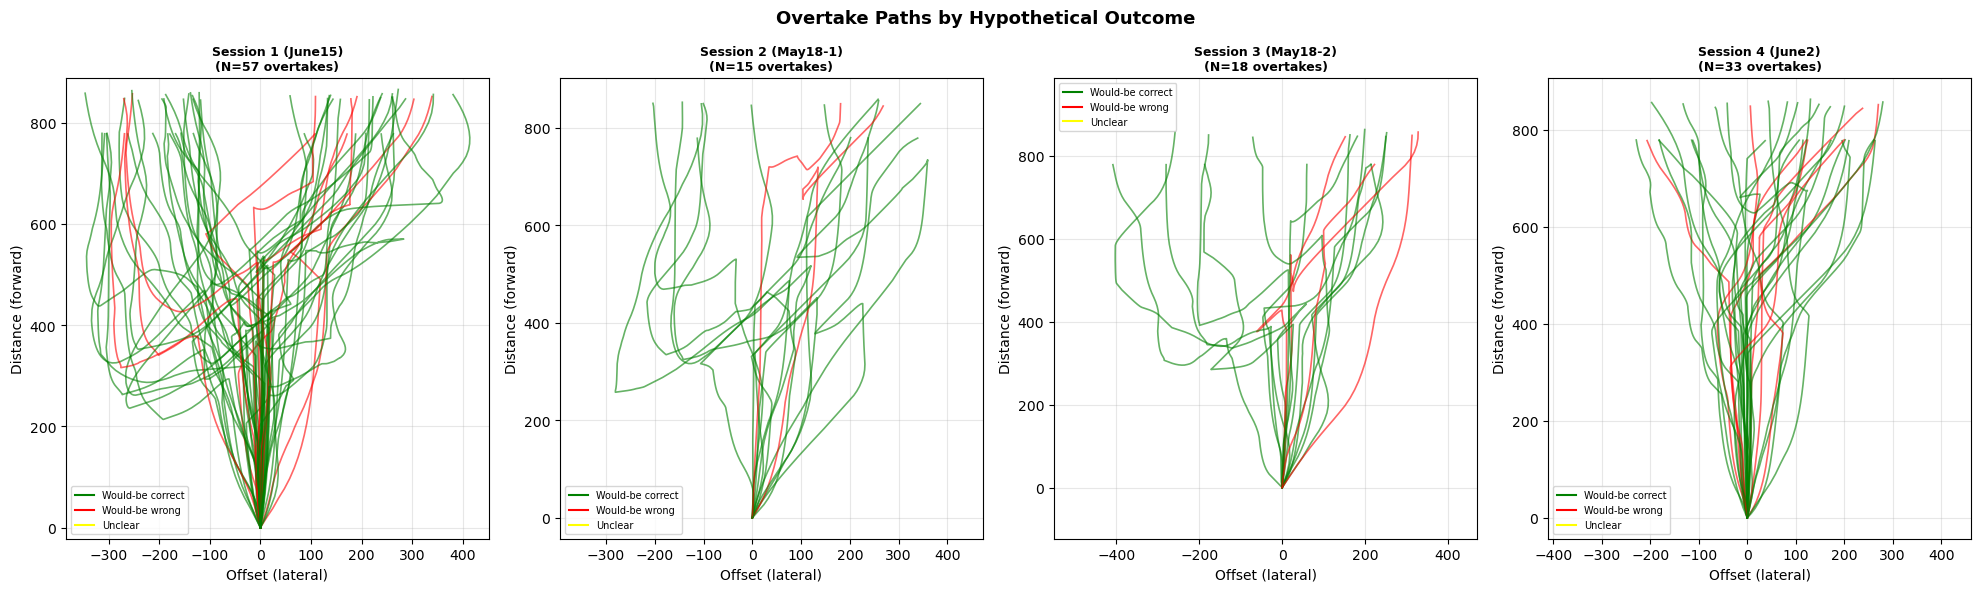

In [18]:
# %%
# ── Step 2: classify overtake trials ──────────────────────────
outcome_styles = {
    "would_be_correct": ("green",  "o", "Would-be correct"),
    "would_be_wrong":   ("red",    "X", "Would-be wrong"),
    "unclear":          ("yellow", "s", "Unclear"),
}

all_overtakes = []

for name, data in sessions.items():
    ot = data[data["Overtake"]].copy()

    def hypothetical_outcome(row):
        if row["hit_side"] is None or row["target_side"] is None:
            return "unclear"
        return "would_be_correct" if row["hit_side"] == row["target_side"] \
               else "would_be_wrong"

    ot["hypothetical_outcome"] = ot.apply(hypothetical_outcome, axis=1)
    ot["hit_stimulus"]    = ot["hit_side"].map({"right": "Stimulus A", "left": "Stimulus B"})
    ot["target_stimulus"] = ot["target_side"].map({"right": "Stimulus A", "left": "Stimulus B"})

    PATH_X_IDX, PATH_Y_IDX = 1, 0
    def get_endpoint(row):
        path = np.asarray(row["Location"])
        if len(path) == 0:
            return np.nan, np.nan
        return path[-1, PATH_X_IDX], path[-1, PATH_Y_IDX]

    ot[["endpoint_x", "endpoint_y"]] = ot.apply(
        lambda r: pd.Series(get_endpoint(r)), axis=1
    )
    ot["session"] = name
    all_overtakes.append(ot)

    # print per-session summary
    print(f"\n{name} — overtake outcomes:")
    print(ot["hypothetical_outcome"].value_counts())

# combine across sessions
all_ot = pd.concat(all_overtakes, ignore_index=True)

# %%
# ── Step 3: overtake paths — one plot per session ─────────────
fig, axes = plt.subplots(1, len(sessions), figsize=(20, 6))

for ax, (name, ot) in zip(axes, 
        {n: all_ot[all_ot["session"]==n] for n in sessions}.items()):
    for _, row in ot.iterrows():
        path = np.asarray(row["Location"])
        color = outcome_styles.get(
            row["hypothetical_outcome"], ("grey", "o", ""))[0]
        ax.plot(path[:, 1], path[:, 0], '-',
                linewidth=1.2, alpha=0.6, color=color)
    for outcome, (color, marker, label) in outcome_styles.items():
        ax.plot([], [], '-', color=color, label=label)
    ax.legend(fontsize=7)
    ax.set_title(f"{name}\n(N={len(ot)} overtakes)",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel("Offset (lateral)")
    ax.set_ylabel("Distance (forward)")
    ax.axis('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle("Overtake Paths by Hypothetical Outcome", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../figures/overtake_paths_all_sessions.png",
            dpi=150, bbox_inches='tight')
plt.show()

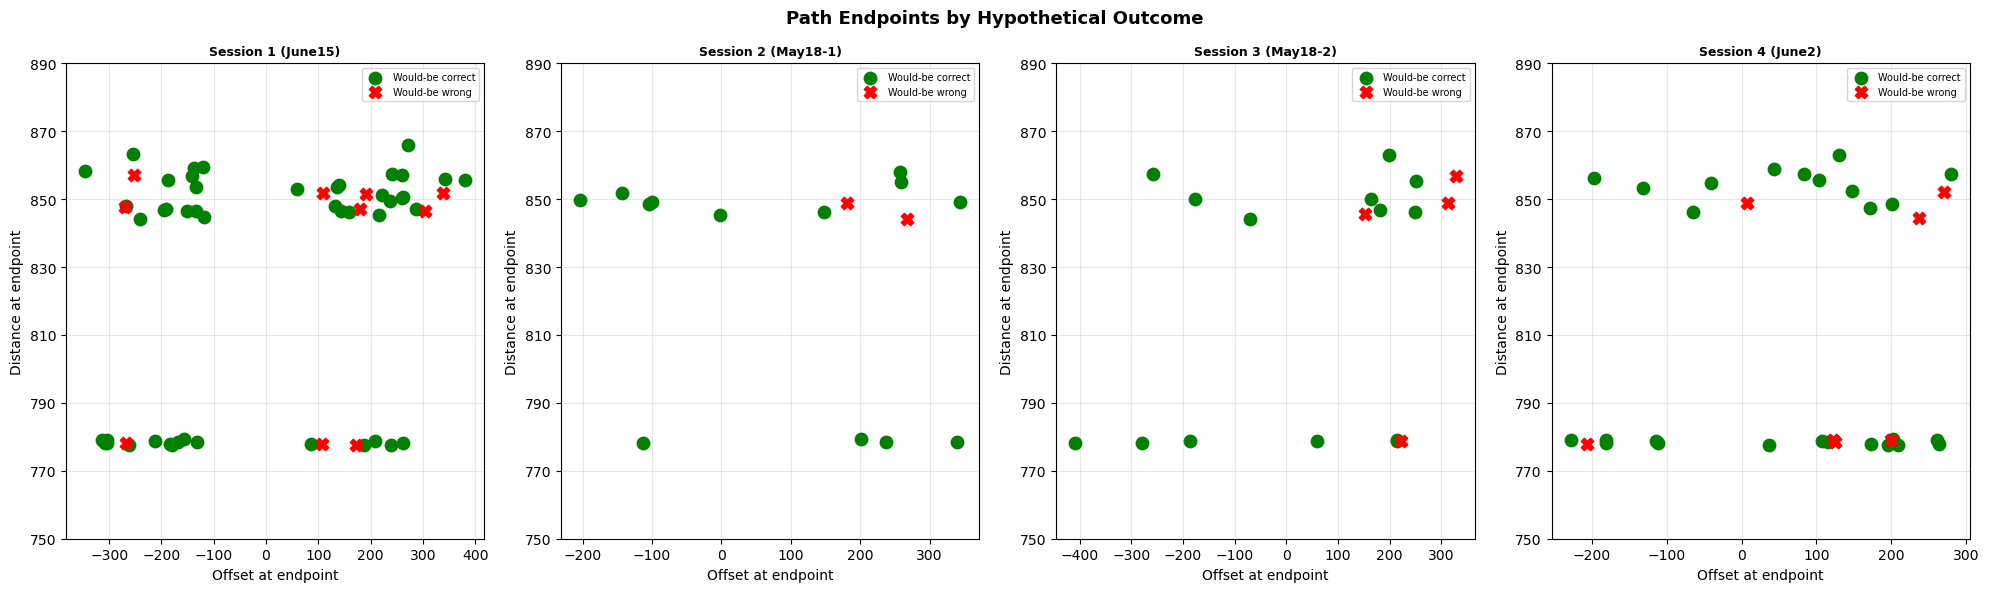

In [19]:
# %%
# ── Step 4: endpoint scatter — one plot per session ───────────
fig, axes = plt.subplots(1, len(sessions), figsize=(20, 6))

for ax, (name, ot) in zip(axes,
        {n: all_ot[all_ot["session"]==n] for n in sessions}.items()):
    for outcome, (color, marker, label) in outcome_styles.items():
        subset = ot[ot["hypothetical_outcome"] == outcome]
        if len(subset) > 0:
            ax.scatter(subset["endpoint_x"], subset["endpoint_y"],
                       c=color, marker=marker, s=80,
                       label=label, zorder=3)
    ax.set_title(f"{name}", fontsize=9, fontweight='bold')
    ax.set_xlabel("Offset at endpoint")
    ax.set_ylabel("Distance at endpoint")
    ax.set_yticks(np.arange(750, 901, 20))
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Path Endpoints by Hypothetical Outcome",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../figures/endpoints_all_sessions.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# %%
# ── Step 5: combined summary across all sessions ───────────────
print("\nCombined overtake outcomes across all sessions:")
print(all_ot["hypothetical_outcome"].value_counts())
print()
print(all_ot.groupby(["session", "hypothetical_outcome"])
           .size()
           .unstack(fill_value=0))


Combined overtake outcomes across all sessions:
hypothetical_outcome
would_be_correct    100
would_be_wrong       23
Name: count, dtype: int64

hypothetical_outcome  would_be_correct  would_be_wrong
session                                               
Session 1 (June15)                  47              10
Session 2 (May18-1)                 13               2
Session 3 (May18-2)                 14               4
Session 4 (June2)                   26               7
